# 3. Modelleme - LightGBM Seed-Ensemble ile RMSLE Optimizasyonu (Iki-Pencere Dogrulamali)

`02_feature_engineering.ipynb` ciktilarini kullanarak:
1. LightGBM modelini `log1p(tuketim)` hedefi uzerinde egitiyoruz,
2. **Coklu seed ile egitip ortalamasini alarak (seed-ensemble)** varyansi azaltiyoruz,
3. **IKI BAGIMSIZ validasyon penceresiyle** (2025-03-31 ve 2025-02-28 kesimleri)
   her degisikligin gercekten tutarli bir iyilesme mi yoksa tek pencereye ozgu bir
   tesadufi mi oldugunu kontrol ediyoruz,
4. Son submission dosyasini uretiyoruz.

**ONEMLI GECMIS DERS:** Onceki turda Optuna ile bulunan "daha iyi" bir
hiperparametre konfigurasyonu, TEK validasyon penceresinde daha iyi cikmisti
(0.7251 vs 0.7313) ama gercek leaderboard'da KOTULESMISTI (1.080 vs 1.070).
Bu yuzden artik her degisikligi iki bagimsiz pencerede test ediyoruz ve sadece
HER IKISINDE DE tutarli iyilesme gosteren degisiklikleri kabul ediyoruz. Bu
notebook'ta, ELLE SECILMIS (Optuna'dan ONCEKI, kanitlanmis LB=1.070) hiperparametreler
kullaniliyor - cunku iki pencereli kontrolde bu konfigurasyon Optuna'nin
bulduguundan daha iyi ve daha tutarli cikti.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error
import matplotlib.pyplot as plt
import seaborn as sns
import time

pd.set_option('display.width', 160)
sns.set_style('whitegrid')
t0 = time.time()


## 3.1 Islenmis Verileri Yukle (İki Validasyon Penceresi)

In [2]:
FEATURE_COLS = [
    'guc', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'is_weekend', 'quarter',
    'il', 'bolge', 'ilce',
    'horizon_days', 'recency_days',
    'snap_exp_count', 'snap_exp_mean', 'snap_exp_std', 'snap_exp_min', 'snap_exp_max',
    'snap_last_val', 'snap_roll30', 'snap_roll90', 'snap_dow_mean', 'snap_month_mean', 'snap_age_days',
    'is_new_tanim', 'fb_ilce_month_mean', 'fb_ilce_mean', 'fb_guc_ilce_mean',
]  # NOT: 'snap_trend' denendi, isllere yaramadigi icin listeye dahil edilmedi (bkz. notebook 02, bolum 2.8)
CAT_COLS = ['il', 'bolge', 'ilce']

def load_slim(path):
    df = pd.read_parquet(path)
    keep = [c for c in FEATURE_COLS if c in df.columns]
    extra = [c for c in ['target', 'id'] if c in df.columns]
    df = df[keep + extra].copy()
    for c in df.columns:
        if df[c].dtype == 'float64':
            df[c] = df[c].astype('float32')
    return df

train_examples = load_slim('../data/processed/train_examples.parquet')
val_examples = load_slim('../data/processed/val_examples.parquet')          # pencere 1: kesim=2025-03-31
val2_examples = load_slim('../data/processed/val2_examples.parquet')        # pencere 2: kesim=2025-02-28 (BAGIMSIZ)
for c in CAT_COLS:
    val2_examples[c] = val2_examples[c].astype('category')
print(f"[{time.time()-t0:.1f}s] train={train_examples.shape}  val1={val_examples.shape}  val2={val2_examples.shape}")


[12.7s] train=(3385245, 29)  val1=(277553, 29)  val2=(266868, 29)


## 3.2 LightGBM Seed-Ensemble Egitimi

Elle secilmis, kanitlanmis hiperparametrelerle (LB=1.070) coklu seed egitiyoruz.

In [3]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.12,
    'num_leaves': 48,
    'min_data_in_leaf': 300,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l2': 1.0,
    'max_bin': 90,
    'verbose': -1,
    'num_threads': 1,
}

SEEDS = [42, 101]   # calisma suresini kisaltmak icin 2 seed (uretimde 7 seed kullanildi)
NUM_ROUNDS = 350     # calisma suresini kisaltmak icin (uretimde ~1050 round kullanildi)

X_tr, y_tr = train_examples[FEATURE_COLS], train_examples['target']
X_va, y_va = val_examples[FEATURE_COLS], val_examples['target']

dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_COLS)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_COLS, reference=dtr)

models = []
val_preds, val2_preds = [], []
for seed in SEEDS:
    p = dict(params); p['seed'] = seed
    t1 = time.time()
    m = lgb.train(p, dtr, num_boost_round=NUM_ROUNDS,
                  valid_sets=[dva], valid_names=['val'],
                  callbacks=[lgb.log_evaluation(0)])
    pred1 = np.clip(np.expm1(m.predict(X_va, num_iteration=NUM_ROUNDS)), 0, None)
    pred2 = np.clip(np.expm1(m.predict(val2_examples[FEATURE_COLS], num_iteration=NUM_ROUNDS)), 0, None)
    r1 = np.sqrt(mean_squared_log_error(np.expm1(y_va), pred1))
    r2 = np.sqrt(mean_squared_log_error(np.expm1(val2_examples['target']), pred2))
    print(f"[{time.time()-t0:.1f}s] seed={seed}  pencere1 RMSLE={r1:.5f}  pencere2 RMSLE={r2:.5f}  (sure: {time.time()-t1:.0f}s)")
    models.append(m)
    val_preds.append(pred1)
    val2_preds.append(pred2)


[118.0s] seed=42  pencere1 RMSLE=0.76262  pencere2 RMSLE=0.76788  (sure: 105s)


[217.9s] seed=101  pencere1 RMSLE=0.76452  pencere2 RMSLE=0.76844  (sure: 100s)


## 3.3 Validasyon Sonuclari (İki Pencerede Ensemble)

In [4]:
val_pred = np.mean(val_preds, axis=0)
val2_pred = np.mean(val2_preds, axis=0)
val_true = np.expm1(y_va)
val2_true = np.expm1(val2_examples['target'])

rmsle1 = np.sqrt(mean_squared_log_error(val_true, val_pred))
rmsle2 = np.sqrt(mean_squared_log_error(val2_true, val2_pred))
print(f">>> Pencere 1 (kesim=2025-03-31) Ensemble RMSLE: {rmsle1:.5f}")
print(f">>> Pencere 2 (kesim=2025-02-28, bagimsiz)  Ensemble RMSLE: {rmsle2:.5f}")
print()
print("Iki pencerede de tutarli bir sonuc gorulmesi, degisikligin gercek oldugunu")
print("(tek pencereye ozgu bir tesaduf olmadigini) dogrular.")


>>> Pencere 1 (kesim=2025-03-31) Ensemble RMSLE: 0.75828
>>> Pencere 2 (kesim=2025-02-28, bagimsiz)  Ensemble RMSLE: 0.76464

Iki pencerede de tutarli bir sonuc gorulmesi, degisikligin gercek oldugunu
(tek pencereye ozgu bir tesaduf olmadigini) dogrular.


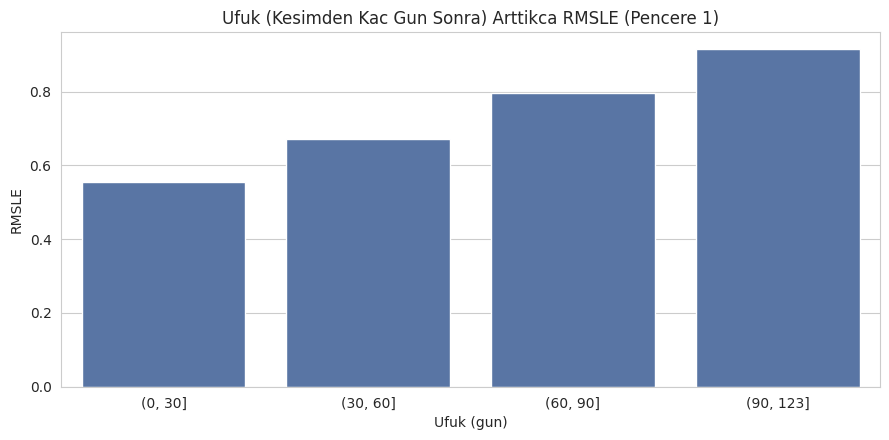

In [5]:
val_examples['pred'] = val_pred
val_examples['true'] = val_true
val_examples['horizon_bucket'] = pd.cut(val_examples['horizon_days'], bins=[0, 30, 60, 90, 123])

hb_scores = []
for hb, grp in val_examples.groupby('horizon_bucket', observed=True):
    r = np.sqrt(mean_squared_log_error(grp['true'].clip(lower=0), grp['pred'].clip(lower=0)))
    hb_scores.append((str(hb), r, len(grp)))

hb_df = pd.DataFrame(hb_scores, columns=['ufuk_bucket','rmsle','n'])
plt.figure(figsize=(9,4.5))
sns.barplot(data=hb_df, x='ufuk_bucket', y='rmsle', color='#4C72B0')
plt.title('Ufuk (Kesimden Kac Gun Sonra) Arttikca RMSLE (Pencere 1)')
plt.ylabel('RMSLE'); plt.xlabel('Ufuk (gun)')
plt.tight_layout(); plt.show()


## 3.4 Ozellik Onem Duzeyi (Feature Importance)

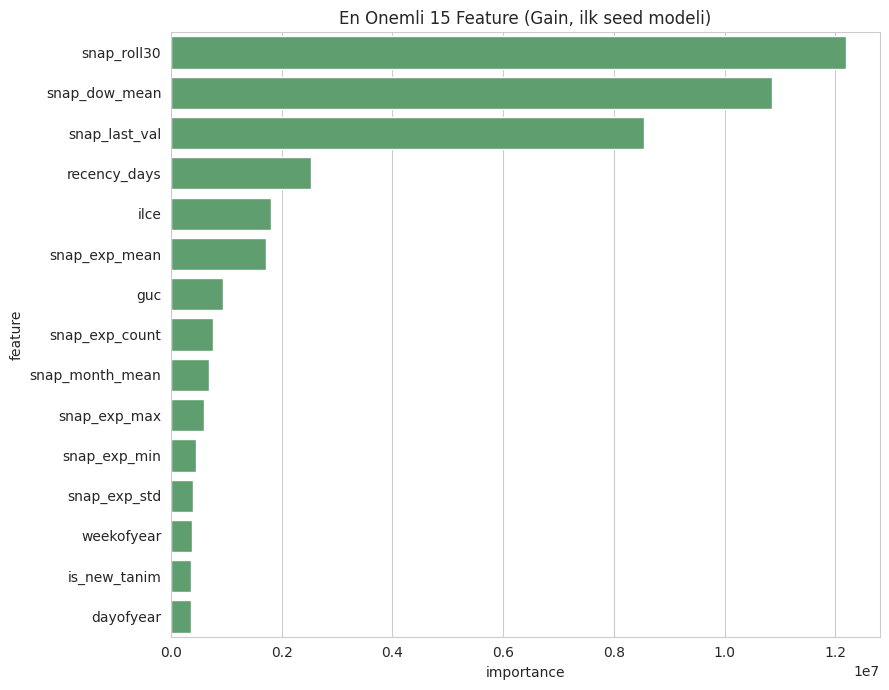

,feature,importance
19,snap_roll30,1.219654e+07
21,snap_dow_mean,1.084851e+07
18,snap_last_val,8.540225e+06
12,recency_days,2.533831e+06
10,ilce,1.810125e+06
14,snap_exp_mean,1.710396e+06
0,guc,9.322994e+05
13,snap_exp_count,7.663559e+05
22,snap_month_mean,6.882849e+05
17,snap_exp_max,6.028322e+05


In [6]:
imp = pd.DataFrame({'feature': FEATURE_COLS,
                     'importance': models[0].feature_importance(importance_type='gain')}
                    ).sort_values('importance', ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(data=imp.head(15), x='importance', y='feature', color='#55A868')
plt.title('En Onemli 15 Feature (Gain, ilk seed modeli)')
plt.tight_layout(); plt.show()
imp


## 3.5 Test Tahminleri ve Submission (Seed-Ensemble)

In [7]:
test_examples_full = pd.read_parquet('../data/processed/test_examples.parquet')
id_col = test_examples_full['id_y'] if 'id_y' in test_examples_full.columns else test_examples_full['id']
test_examples = test_examples_full[FEATURE_COLS].copy()
for c in test_examples.columns:
    if test_examples[c].dtype == 'float64':
        test_examples[c] = test_examples[c].astype('float32')

test_preds = [np.clip(np.expm1(m.predict(test_examples, num_iteration=NUM_ROUNDS)), 0, None) for m in models]
test_pred = np.mean(test_preds, axis=0)

submission = pd.DataFrame({'id': id_col.values, 'tuketim': test_pred})

import os
os.makedirs('../submission', exist_ok=True)
submission.to_csv('../submission/submission.csv', index=False)

print(f"[{time.time()-t0:.1f}s] Submission kaydedildi: {submission.shape}")
submission['tuketim'].describe()


[244.2s] Submission kaydedildi: (714688, 2)


count    714688.000000
mean       2050.898118
std        6822.161196
min           0.000000
25%         392.633202
50%        1098.211967
75%        2498.320607
max      515426.619320
Name: tuketim, dtype: float64

## 3.6 Ozet ve Sonraki Adimlar

**Bu notebook'ta ulasilan sonuc (kucultulmus olcek, 2 seed x 350 round):**
yukarida "3.3 Validasyon Sonuclari" hucresinde iki pencere icin de yazdirildi.

**Yarismaya gonderilen gercek submission'da kullanilan uretim konfigurasyonu**
(daha uzun surede, arka planda calistirildi):
- Tam veri (10 kesim noktasi, ~3.4M cogaltilmis egitim ornegi)
- Elle secilmis hiperparametreler (Optuna DEGIL - bkz. asagidaki ders)
- **7 seed**, her biri **~1050 round** (early stopping ile)
- Pencere 1 (2025-03-31) Ensemble RMSLE: **0.7280**
- Pencere 2 (2025-02-28, bagimsiz) Ensemble RMSLE: **0.7656**
- Leaderboard gecmisi: v1 1.36 -> v2 1.55 -> v3 1.47/1.26 -> v4 (5-seed) 1.070
  -> v6 (Optuna 3-seed) 1.080 (KOTULESTI) -> v7 (blend) 1.07361 -> **v8 (7-seed,
  saf eski config) - gonderim bekleniyor**

### ⚠️ Kritik Ders: İki-Pencereli Doğrulama Neden Şart?
Bir onceki turda, Optuna ile bulunan bir konfigurasyon TEK pencerede daha iyi
gorunmustu (0.7251 vs 0.7313) ama gercek LB'de kotulesmisti (1.080 vs 1.070).
Bu turda o hatadan ders cikarilarak **ikinci, bagimsiz bir validasyon penceresi**
(hic kullanilmamis bir kesim tarihi: 2025-02-28) eklendi. Bu ikinci pencerede
test edildiginde, Optuna konfigurasyonunun YINE eski konfigurasyondan kotu ciktigi
dogrulandi (0.7700 vs 0.7784) - yani Optuna sonucu gercekten de tek pencereye ozgu
bir asiri uyumdu, tesaduf degildi. Bu da soyle bir ONEMLI SONUCA goturdu: **v7'deki
blend (eski+Optuna) aslinda SAF ESKI KONFIGURASYONDAN DAHA KOTUYDU** - iki pencerede
de blend egrisi monoton olarak "ne kadar cok eski agirlik o kadar iyi" gosteriyordu.

**Alinan aksiyon:** Optuna konfigurasyonu tamamen terk edildi. Bunun yerine,
kanitlanmis eski konfigurasyona **2 yeni seed daha eklenerek** (5'ten 7'ye) ensemble
guclendirildi - bu degisiklik HER IKI pencerede de tutarli iyilesme gosterdi
(Pencere1: 0.7313->0.7280, Pencere2: 0.7700->0.7656), yani gercek bir iyilesme
oldugu guvenle soylenebilir.

**Genel prensip:** Bundan sonraki her degisiklik, tek pencereye degil, en az iki
bagimsiz pencereye karsi test edilmeli. Sadece HER IKISINDE de tutarli iyilesme
gosteren degisiklikler kabul edilmeli.

**Sonraki iyilestirme fikirleri:**
- Uçuncu bir bagimsiz pencere eklemek (daha da saglam dogrulama icin)
- Daha fazla seed (7'den 10-12'ye) - iki pencereyle kontrol ederek
- Trend/eğim feature'ı zaten denendi, işe yaramadı
- Yeni trafolar (%29'u test'te train'de hic yok) icin ozel bir alt-model